# SIOC 251 - Homework 3 Monte Carlo Scattering

**Name:** Myles Jacobs

**Date:** 5/13/26

## Part 1: Isotropic Scattering

### 5.1: Model Construction

In [1]:
import numpy as np

def run_monte_carlo_scattering(num_photons, tau_star, omega, theta_deg, z_atm=1.0):
    """
    Simulates radiative transfer with isotropic scattering.
    
    Parameters:
    - num_photons: Number of photons entering the atmosphere.
    - tau_star: Total optical depth of the atmosphere.
    - omega: Single scatter albedo (probability of scattering vs absorption).
    - theta_deg: Solar zenith angle in degrees.
    - z_atm: Geometric thickness of the atmosphere.
    
    Returns:
    - A dictionary containing albedo, direct/diffuse/total transmittance, and absorptance.
    """
    if theta_deg >= 90.0:
        return {"albedo": 1.0, "total_transmittance": 0.0, "absorptance": 0.0}

    # Initial incoming angles
    theta_rad = np.radians(theta_deg)
    phi_rad = 0.0 # Arbitrary incoming azimuth

    # 1. Initialize photon directions and positions
    # kz is negative because photons enter traveling downward towards the surface
    kx = np.sin(theta_rad) * np.cos(phi_rad) * np.ones(num_photons)
    ky = np.sin(theta_rad) * np.sin(phi_rad) * np.ones(num_photons)
    kz = -np.cos(theta_rad) * np.ones(num_photons) 
    
    # All photons start at the top of the atmosphere
    z = np.full(num_photons, z_atm)

    # Tracking arrays
    active = np.ones(num_photons, dtype=bool)
    scatters = np.zeros(num_photons, dtype=int)

    # Outcome arrays
    reflected = np.zeros(num_photons, dtype=bool)
    transmitted = np.zeros(num_photons, dtype=bool)
    absorbed = np.zeros(num_photons, dtype=bool)

    # Mean free path in geometric units
    mfp = z_atm / tau_star

    # Loop until all photons have either exited or been absorbed
    while np.any(active):
        N_active = np.sum(active)

        # Step 1: Calculate the sampled optical depth traveled by each active photon
        zeta = np.random.uniform(0, 1, N_active)
        L = -mfp * np.log(1 - zeta)

        # Step 2: Move photons along their current trajectory
        z[active] += L * kz[active]

        # Step 3: Check boundaries to see if photons hit the ground or exited the top
        hit_ground = z <= 0
        hit_top = z >= z_atm

        just_transmitted = active & hit_ground
        just_reflected = active & hit_top

        transmitted[just_transmitted] = True
        reflected[just_reflected] = True

        # Deactivate photons that have exited the atmosphere
        active[just_transmitted | just_reflected] = False

        # Step 4: Process interactions for photons still inside the atmosphere
        interacting = active.copy()
        N_int = np.sum(interacting)
        if N_int == 0:
            break

        # Step 5: Determine Scattering vs Absorption
        zeta_omega = np.random.uniform(0, 1, N_int)
        is_scatter = zeta_omega < omega

        # Handle Absorption
        is_absorbed = ~is_scatter
        absorbed_global = np.zeros(num_photons, dtype=bool)
        absorbed_global[interacting] = is_absorbed
        
        absorbed[absorbed_global] = True
        active[absorbed_global] = False # Deactivate absorbed photons

        # Handle Scattering
        scatter_global = np.zeros(num_photons, dtype=bool)
        scatter_global[interacting] = is_scatter
        scatters[scatter_global] += 1

        N_scat = np.sum(scatter_global)
        if N_scat > 0:
            # Step 6: Generate Isotropic Scattering Angles
            u = np.random.uniform(0, 1, N_scat)
            
            # Uniform in cos(Theta)
            cos_Theta = 2 * u - 1
            sin_Theta = np.sqrt(1 - cos_Theta**2)
            
            # Uniform in Phi (0 to 2*pi)
            Phi = np.random.uniform(0, 2 * np.pi, N_scat)

            # Scattered direction in the photon's local coordinate system
            kp_x = sin_Theta * np.cos(Phi)
            kp_y = sin_Theta * np.sin(Phi)
            kp_z = cos_Theta

            # Step 7: Coordinate Rotation (Appendix A)
            kx_s = kx[scatter_global]
            ky_s = ky[scatter_global]
            kz_s = kz[scatter_global]

            # Z_p axis (incoming direction)
            zp_x, zp_y, zp_z = kx_s, ky_s, kz_s

            # X_p axis
            norm_xy = np.sqrt(kx_s**2 + ky_s**2)
            xp_x = np.zeros_like(kx_s)
            xp_y = np.zeros_like(ky_s)
            xp_z = np.zeros_like(kz_s)

            # Handle the special case where photon is traveling exactly vertically
            vertical = norm_xy < 1e-8
            not_vertical = ~vertical

            if np.any(vertical):
                xp_x[vertical] = 1.0
                xp_y[vertical] = 0.0
                xp_z[vertical] = 0.0

            if np.any(not_vertical):
                xp_x[not_vertical] = -ky_s[not_vertical] / norm_xy[not_vertical]
                xp_y[not_vertical] = kx_s[not_vertical] / norm_xy[not_vertical]
                xp_z[not_vertical] = 0.0

            # Y_p axis = Z_p cross X_p
            yp_x = zp_y * xp_z - zp_z * xp_y
            yp_y = zp_z * xp_x - zp_x * xp_z
            yp_z = zp_x * xp_y - zp_y * xp_x

            # Rotate scattered vector into model coordinates
            knew_x = kp_x * xp_x + kp_y * yp_x + kp_z * zp_x
            knew_y = kp_x * xp_y + kp_y * yp_y + kp_z * zp_y
            knew_z = kp_x * xp_z + kp_y * yp_z + kp_z * zp_z

            # Normalize to avoid numerical drift over many scatters
            norm_knew = np.sqrt(knew_x**2 + knew_y**2 + knew_z**2)
            kx[scatter_global] = knew_x / norm_knew
            ky[scatter_global] = knew_y / norm_knew
            kz[scatter_global] = knew_z / norm_knew

    # Calculate final statistics
    direct = transmitted & (scatters == 0)
    diffuse = transmitted & (scatters > 0)

    return {
        "direct_transmittance": np.sum(direct) / num_photons,
        "diffuse_transmittance": np.sum(diffuse) / num_photons,
        "total_transmittance": np.sum(transmitted) / num_photons,
        "albedo": np.sum(reflected) / num_photons,
        "absorptance": np.sum(absorbed) / num_photons
    }

# --- Execution Example ---
# Simulating 100,000 photons, tau=1.0, omega=0.8 (some absorption), solar zenith=0 deg
results = run_monte_carlo_scattering(num_photons=100000, tau_star=1.0, omega=0.8, theta_deg=0.0)

print("--- Results ---")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance: {results['diffuse_transmittance']:.4f}")
print(f"Total Transmittance:   {results['total_transmittance']:.4f}")
print(f"Albedo (Reflected):    {results['albedo']:.4f}")
print(f"Absorptance:           {results['absorptance']:.4f}")
print(f"Total Sum (Check):     {sum([results['total_transmittance'], results['albedo'], results['absorptance']]):.4f}")

--- Results ---
Direct Transmittance:  0.3683
Diffuse Transmittance: 0.1749
Total Transmittance:   0.5433
Albedo (Reflected):    0.2087
Absorptance:           0.2480
Total Sum (Check):     1.0000


### 5.2 Verification test one

When there is no atmosphere (z=0.0, direct transmittance should be the only component of radiation. With no atmosphere to absorb either, the albedo should thus be equal to the direct transmittance. The resulting output, thus, should read 0s in diffuse and absorptance, and 1.0 in every other category.

In [7]:
import numpy as np

# Define no atmosphere
num_photons = 1000000
omega = 0.8
results = run_monte_carlo_scattering(num_photons, tau_star, omega, theta_deg, z_atm=0.0)

print("--- Results ---")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance: {results['diffuse_transmittance']:.4f}")
print(f"Total Transmittance:   {results['total_transmittance']:.4f}")
print(f"Albedo (Reflected):    {results['albedo']:.4f}")
print(f"Absorptance:           {results['absorptance']:.4f}")
print(f"Total Sum (Check):     {sum([results['total_transmittance'], results['albedo'], results['absorptance']]):.4f}")

--- Results ---
Direct Transmittance:  1.0000
Diffuse Transmittance: 0.0000
Total Transmittance:   1.0000
Albedo (Reflected):    1.0000
Absorptance:           0.0000
Total Sum (Check):     2.0000


### 5.2 Verification test one results

As predicted, diffuse and absorptance read 0.0, while the others (except the total sum) read 1.0. This makes sense.


### 5.2 Verification test two

 The second verification test will be for the next limiting case: where no light reaches the surface directly, and all is either scattered or absorbed (such as for an extremely overcast day). To model this, we will make tau_star an incredibly high value.

In [8]:
import numpy as np

# Define no atmosphere
num_photons = 1000000
omega = 0.8
tau_star = 100
results = run_monte_carlo_scattering(num_photons, tau_star, omega, theta_deg, z_atm=1.0)

print("--- Results ---")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance: {results['diffuse_transmittance']:.4f}")
print(f"Total Transmittance:   {results['total_transmittance']:.4f}")
print(f"Albedo (Reflected):    {results['albedo']:.4f}")
print(f"Absorptance:           {results['absorptance']:.4f}")
print(f"Total Sum (Check):     {sum([results['total_transmittance'], results['albedo'], results['absorptance']]):.4f}")

--- Results ---
Direct Transmittance:  0.0000
Diffuse Transmittance: 0.0000
Total Transmittance:   0.0000
Albedo (Reflected):    0.3029
Absorptance:           0.6971
Total Sum (Check):     1.0000


### 5.2 Verification test two results

As predicted, direct and diffuse transmittance drop to zero, meaning no radiation makes it to the surface. The rest is absorbed or reflected. This makes sense for such an incredibly high optical depth.

### 5.3 Questions

a. $\omega$ increases $0 \rightarrow 1$, how do surface direct and diffuse transmittance, and the albedo, change? Let's plot it:

Running simulations...
Simulations complete. Generating plot...


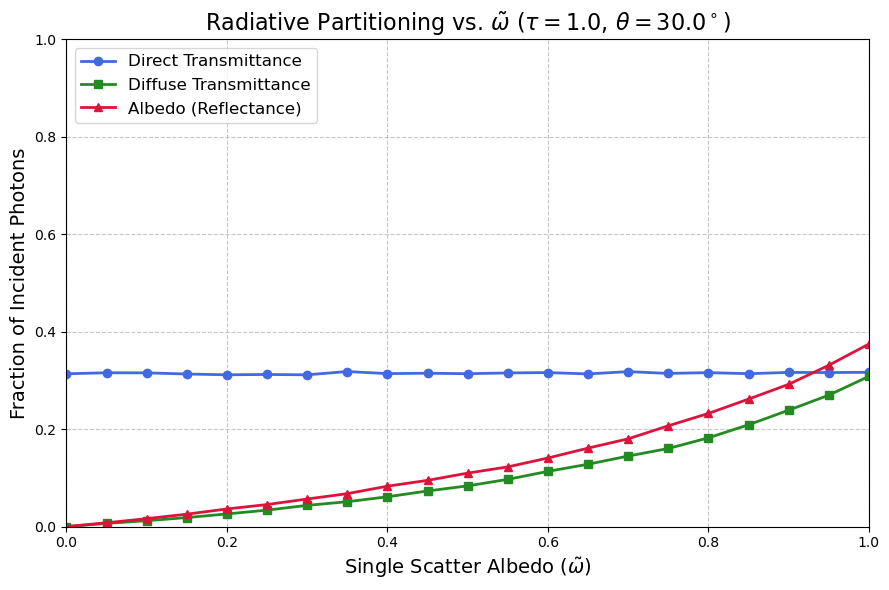

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Define parameters for the experiment
num_photons = 50000  # 50,000 provides a good balance of speed and smooth curves
tau_star = 1.0       # Moderate optical depth
theta_deg = 30.0     # Sun is 30 degrees off zenith
omega_values = np.linspace(0, 1, 21) # 21 points from 0.0 to 1.0

# Initialize lists to store the results
direct_T = []
diffuse_T = []
albedo_R = []

print("Running simulations...")
for w in omega_values:
    # Run the model for each value of omega
    res = run_monte_carlo_scattering(num_photons, tau_star, w, theta_deg)
    
    # Extract and store the relevant quantities
    direct_T.append(res["direct_transmittance"])
    diffuse_T.append(res["diffuse_transmittance"])
    albedo_R.append(res["albedo"])

print("Simulations complete. Generating plot...")

# --- Plotting ---
plt.figure(figsize=(9, 6))

# Plot the three quantities
plt.plot(omega_values, direct_T, label='Direct Transmittance', color='royalblue', marker='o', linewidth=2)
plt.plot(omega_values, diffuse_T, label='Diffuse Transmittance', color='forestgreen', marker='s', linewidth=2)
plt.plot(omega_values, albedo_R, label='Albedo (Reflectance)', color='crimson', marker='^', linewidth=2)

plt.xlabel(r'Single Scatter Albedo ($\tilde{\omega}$)', fontsize=14)
plt.ylabel('Fraction of Incident Photons', fontsize=14)
plt.title(fr'Radiative Partitioning vs. $\tilde{{\omega}}$ ($\tau={tau_star}$, $\theta={theta_deg}^\circ$)', fontsize=16)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/figure1_albedo_vs_omega.png', dpi=300, bbox_inches='tight')

plt.show()

Discussion: Direct transmittance remains flat because it only depends upon optical depth and slant path. $\omega$ only dictates what happens after an interaction occurs, so it does not change the fraction of particles that never interact. Diffuse transmittance and albedo both increase non-linearly, starting at 0 for a purely absorbing atmosphere as nothing is scattered, and increasing in similar patterns as scattering becomes the dominant interaction type, both scattering upwards out of the atmosphere and downwards toward the surface.

b. For $\tau << 1$: 

The beer lambert law for direct transmittance is $e^{-\tau/\mu_{0}}$, and for very small $\tau$, $1-e^{-x} = x$, so the probability of interaction then becomes $\tau/\mu_{0}$. The probability of scattering is determined by the single scatter albedo, $\omega$. The probability of a photon reaching the surface, under isotropic single-scattering, is exactly 0.5. Multiplying these probabilities gives us the relationship between diffuse radiation, the single scattering albedo, the optical depth, and the cosine of the zenith angle ($\mu_{0} = cos(\theta)$).

Therefore, the analytical relationship for an optically thin atmosphere with isotropic scattering is:
$$T_{diff} = \omega_{\tau}/(2\mu_{0})$$

Which IS the approximate solution to the RTE, simplified by dropping the multiple-scattering integral. We can prove that our model, for very large amount of photons, approaches the theoretical diffuse transmittance:

In [5]:
import numpy as np

# Define optically thin parameters
tau_thin = 0.05
omega_val = 0.8
theta_val = 60.0
mu_0 = np.cos(np.radians(theta_val))

# Run the model with a high photon count to resolve small probabilities accurately
num_photons = 1_000_000
results = run_monte_carlo_scattering(num_photons, tau_thin, omega_val, theta_val)

# Calculate theoretical diffuse transmittance
theoretical_diffuse = (omega_val * tau_thin) / (2 * mu_0)

print("--- Thin Atmosphere Verification ---")
print(f"Model Diffuse Transmittance:       {results['diffuse_transmittance']:.5f}")
print(f"Theoretical Diffuse Transmittance: {theoretical_diffuse:.5f}")

--- Thin Atmosphere Verification ---
Model Diffuse Transmittance:       0.03700
Theoretical Diffuse Transmittance: 0.04000


c. In order to prove that the sky is blue and sunsets are red, we manipulate the zenith angle of the sun, as well as the optical depth for each color's wavelength ($\tau = 0.02$ for red light and 0.2 for blue) and see how in each case the diffuse transmittance of each color compares. For the sun high in the sky, we should see diffuse transmittance of blue appearing dominant. This means that blue is scattered more, giving the sky its blue color. In the other case for sunset, we should see that direct transmittance of blue light almost disappears, while red light remains, which gives sunsets their red color.

In [14]:
import numpy as np

# Define blue, midday parameters
tau_blue = 0.2
omega_val = 0.8
theta_midday = 0.0
mu_0 = np.cos(np.radians(theta_midday))

num_photons = 1_000_000
results = run_monte_carlo_scattering(num_photons, tau_blue, omega_val, theta_midday)

print("--- Midday Values ---")
print(f"Model Diffuse Transmittance:       {results['diffuse_transmittance']:.5f}")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")

--- Midday Values ---
Model Diffuse Transmittance:       0.06696
Direct Transmittance:  0.8193


In [15]:
import numpy as np

# Define red, midday parameters
tau_red = 0.02
omega_val = 0.8
theta_midday = 0.0
mu_0 = np.cos(np.radians(theta_midday))

num_photons = 1_000_000
results = run_monte_carlo_scattering(num_photons, tau_red, omega_val, theta_midday)

print("--- Midday Values ---")
print(f"Model Diffuse Transmittance:       {results['diffuse_transmittance']:.5f}")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")

--- Midday Values ---
Model Diffuse Transmittance:       0.00785
Direct Transmittance:  0.9803


As predicted, diffuse transmittance of blue light is almost tenfold that of red light for theta=0.0, representing the middle of the day. Now, let's test this again for theta=85deg, when the sun is close to the horizon:

In [20]:
import numpy as np

# Define blue, sunset parameters
tau_blue = 0.2
omega_val = 0.8
theta_sunset = 85.0
mu_0 = np.cos(np.radians(theta_sunset))

num_photons = 1_000_000
results = run_monte_carlo_scattering(num_photons, tau_blue, omega_val, theta_sunset)

print("--- Sunset Values ---")
print(f"Model Diffuse Transmittance:       {results['diffuse_transmittance']:.5f}")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")

--- Sunset Values ---
Model Diffuse Transmittance:       0.30933
Direct Transmittance:  0.1006


In [19]:
import numpy as np

# Define red, sunset parameters
tau_red = 0.02
omega_val = 0.8
theta_sunset = 85.0
mu_0 = np.cos(np.radians(theta_sunset))

num_photons = 1_000_000
results = run_monte_carlo_scattering(num_photons, tau_red, omega_val, theta_sunset)

print("--- Sunset Values ---")
print(f"Model Diffuse Transmittance:       {results['diffuse_transmittance']:.5f}")
print(f"Direct Transmittance:  {results['direct_transmittance']:.4f}")

--- Sunset Values ---
Model Diffuse Transmittance:       0.08080
Direct Transmittance:  0.7949


As predicted, the direct transmittance of blue light at the horizon is close to zero, while red light is still at about 80%. This means that most blue light has scattered in other directions, while red survives the longer path length.

d. Student Investigation

Let us investigate the effect of clouds and aerosols on transmittance and albedo. Cloud/aerosol concentration can be modeled by varying the value of $\tau$, and plotting the resulting transmittance and albedo. Because high values of $\tau$ (such as $\tau=100$) can lead to single photons bouncing around 10,000 times, we will avoid frying my CPU by using a logarithmic scale. 

Running cloud optical depth simulations. This may take a moment for higher tau...
Completed tau = 0.1
Completed tau = 0.1
Completed tau = 0.2
Completed tau = 0.3
Completed tau = 0.4
Completed tau = 0.5
Completed tau = 0.7
Completed tau = 1.0
Completed tau = 1.4
Completed tau = 1.9
Completed tau = 2.6
Completed tau = 3.7
Completed tau = 5.1
Completed tau = 7.0
Completed tau = 9.8
Completed tau = 13.5
Completed tau = 18.8
Completed tau = 26.0
Completed tau = 36.1
Completed tau = 50.1
Simulations complete. Generating plot...


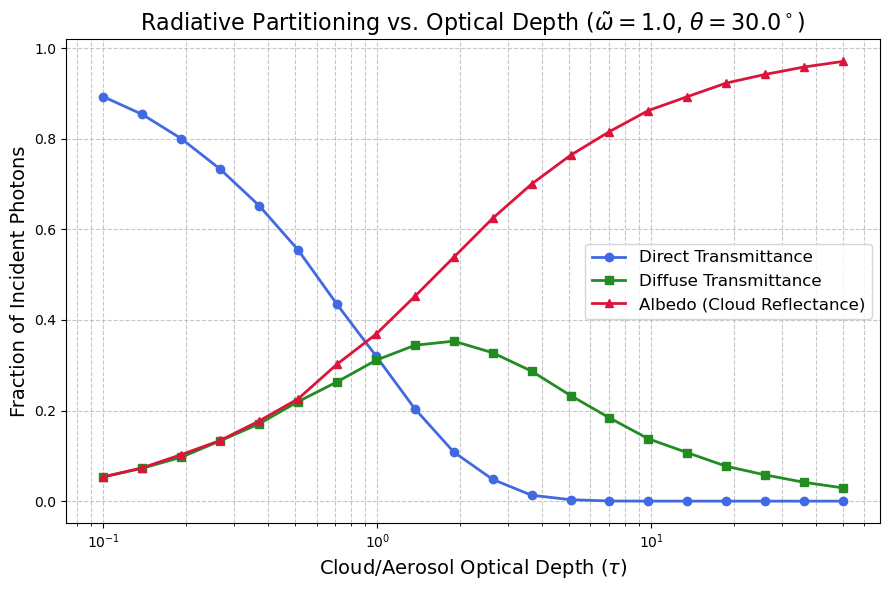

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Define parameters for the experiment
num_photons = 20000  # Slightly reduced to handle high tau efficiently
omega_val = 1.0      # Pure scattering (conservative cloud/aerosol)
theta_deg = 30.0     # Sun is 30 degrees off zenith

# Use log space to capture both thin aerosols and thick clouds efficiently
# 20 points from 10^-1 (0.1) to 10^1.7 (approx 50)
tau_values = np.logspace(-1, 1.7, 20) 

# Initialize lists to store the results
direct_T = []
diffuse_T = []
albedo_R = []

print("Running cloud optical depth simulations. This may take a moment for higher tau...")
for t in tau_values:
    # Run the model for each optical depth
    res = run_monte_carlo_scattering(num_photons, t, omega_val, theta_deg)
    
    # Extract and store the relevant quantities
    direct_T.append(res["direct_transmittance"])
    diffuse_T.append(res["diffuse_transmittance"])
    albedo_R.append(res["albedo"])
    
    print(f"Completed tau = {t:.1f}")

print("Simulations complete. Generating plot...")

# --- Plotting ---
plt.figure(figsize=(9, 6))

# Plot the three quantities
plt.plot(tau_values, direct_T, label='Direct Transmittance', color='royalblue', marker='o', linewidth=2)
plt.plot(tau_values, diffuse_T, label='Diffuse Transmittance', color='forestgreen', marker='s', linewidth=2)
plt.plot(tau_values, albedo_R, label='Albedo (Cloud Reflectance)', color='crimson', marker='^', linewidth=2)

# Formatting the plot
plt.xscale('log') # Log scale for the x-axis shows the transition beautifully
plt.xlabel(r'Cloud/Aerosol Optical Depth ($\tau$)', fontsize=14)
plt.ylabel('Fraction of Incident Photons', fontsize=14)
plt.title(fr'Radiative Partitioning vs. Optical Depth ($\tilde{{\omega}}={omega_val}$, $\theta={theta_deg}^\circ$)', fontsize=16)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='center right')

plt.tight_layout()

# --- Save the Figure ---
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/figure2_radiative_effects_vs_tau.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

The plots for direct transmittance and albedo are somewhat easily explainable. As clouds and aerosols thicken, less and less light can reach the surface directly as more of it is scattered or absorbed (though, in this case there is no absorbance, as we've set $\omega = 1$. Similarly, more clouds mean more chances to reflect bback up and out of the atmosphere. Eventually, an atmosphere so thick will reflect all incoming light. Interestingly, diffuse transmittance rises, peaks, and falls once again. For thin layers, that is, low $\tau$, there isn't that many particles to scatter or reflect the beam, so most or all of the light strikes the surface directly. As the atmosphere thickens, more light scatters and hits the surface at the bottom of the atmosphere indirectly. However, when the layers in the atmosphere get too thick, no light can reach the bottom anymore, and it all ends up reflected (as seen by the albedo plot), therefore the diffuse transmittance to the surfaces falls back to zero.

### AI Usage

+ Tool Used: Gemini (Google)
+ How it was used: Gemini generated the bulk of the code of the original model, as well as the figures.
+ Parts checked independently: Model was verified at limiting cases by hand. (Section 5.2)
+ Blue/red light proof also done independently. (Section 5.3c)
  